<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
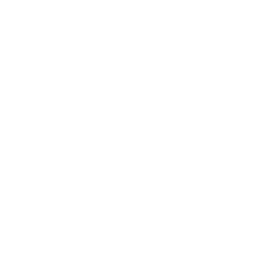
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Delineamento em Parcelas Subdivididas para Otimização de Processo</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Manufatura / Engenharia da Qualidade &nbsp;|&nbsp; Março de 2026</p>
</div>
</div>
</div>

## Resumo Executivo

Este notebook analisa um experimento planejado em parcelas subdivididas para um processo de moldagem por injeção. O fator de parcela principal é a **máquina** (4 níveis: MACH_A-MACH_D), que é difícil de alterar, e o fator de subparcela é o **ajuste de velocidade** (5 níveis: 60, 80, 100, 120, 140 RPM), que é fácil de alterar. Cinco medições replicadas são feitas em cada combinação máquina x velocidade, totalizando 100 observações de taxa de defeitos.

`PROC MIXED` ajusta corretamente a estrutura de randomização restrita ao tratar a **máquina como efeito aleatório** (o estrato de erro da parcela principal) e a **velocidade como efeito fixo** (o fator de subparcela). A análise estima os dois componentes de variância, testa o efeito da velocidade e produz comparações par a par ajustadas por Tukey das médias de mínimos quadrados da velocidade para identificar a velocidade de operação que minimiza a taxa de defeitos.

## Fontes de Dados

| Fonte | Descrição | Registros |
|--------|-------------|--------|
| WORK.MOLDING_EXPERIMENT | Dados experimentais em parcelas subdivididas: 4 máquinas x 5 velocidades x 5 réplicas | 100 |

---

In [1]:
/* --------------------------------------------------------
   Gerar dados sintéticos de moldagem por injeção em parcelas subdivididas
   4 máquinas (parcela principal) x 5 velocidades (subparcela) x 5 réplicas
   Réplicas adicionais para cada parcela principal
   -------------------------------------------------------- */
DADOS work.molding_experiment;
    CHAMAR streaminit(42);
    VETOR machine_names[4] $12 _temporary_ ('MACH_A' 'MACH_B' 'MACH_C' 'MACH_D');
    VETOR speed_settings[5] _temporary_ (60 80 100 120 140);
    /* Efeitos verdadeiros da máquina (aleatórios) */
    VETOR mach_eff[4] _temporary_ (2.1 -1.5 0.8 -1.4);
    /* Efeitos verdadeiros da velocidade (fixos, quadráticos com ótimo ~100) */
    VETOR speed_eff[5] _temporary_ (3.2 1.0 -0.5 0.8 4.5);
    obs_id = 0;
    FAZER whole_plot = 1 ATÉ 5;
        FAZER m = 1 ATÉ 4;
            machine = machine_names[m];
            machine_id = cat('WP_', PUT(whole_plot, z2.), '_', machine);
            /* Efeito de réplica da parcela principal */
            wp_noise = rand('normal', 0, 1.5);
            FAZER s = 1 ATÉ 5;
                speed = speed_settings[s];
                speed_label = cat(PUT(speed, 3.), 'RPM');
                /* Réplicas de subparcela dentro de cada parcela principal */
                FAZER rep = 1 ATÉ 5;
                    obs_id + 1;
                    /* Taxa de defeitos: intercepto + máquina + velocidade + interação + ruído */
                    defect_rate = round(
                        8.0 + mach_eff[m] + speed_eff[s] +
                        wp_noise +
                        0.3 * (m - 2) * (s - 3) +
                        rand('normal', 0, 1.2),
                    0.01);
                    SE defect_rate < 0 ENTÃO defect_rate = 0.01;
                    /* Resposta secundária: resistência à tração */
                    tensile_strength = round(
                        45 - 0.5 * defect_rate +
                        rand('normal', 0, 2),
                    0.1);
                    SAÍDA;
                FIM;
            FIM;
        FIM;
    FIM;
    REMOVER m s mach_eff1-mach_eff4 speed_eff1-speed_eff5 wp_noise;
EXECUTAR;


NOTE: DATA work.molding_experiment

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.molding_experiment (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.05 seconds
  cpu   0.05 seconds


---

In [2]:
/* --------------------------------------------------------
   Linha de base: resumo da taxa de defeitos por máquina e velocidade
   -------------------------------------------------------- */
PROCEDIMENTO MÉDIAS DADOS=work.molding_experiment n mean std;
    CLASSE machine speed_label;
    VARIÁVEL defect_rate tensile_strength;
    LABEL machine="Máquina" speed_label="Velocidade (RPM)"
          defect_rate="Taxa de Defeitos (%)" tensile_strength="Resistência à Tração";
    TÍTULO 'Taxa de Defeitos e Resistência à Tração por Máquina e Velocidade';
EXECUTAR;

                            Taxa de Defeitos e Resistência à Tração por Máquina e Velocidade                            

                                                  The MEANS Procedure

                                  Analysis Variable : defect_rate Taxa de Defeitos (%)

        Máquina   Velocidade (RPM)          N Obs           Mean        Std Dev
        -----------------------------------------------------------------------
        MACH_A     60RPM                        5     12.9460000      1.0100149
        MACH_A     80RPM                        5     10.0160000      0.6740401
        MACH_A    100RPM                        5      7.5980000      0.9787083
        MACH_A    120RPM                        5     10.2660000      0.9490416
        MACH_A    140RPM                        5     13.7120000      0.9359594
        MACH_B     60RPM                        5     11.7420000      0.9476656
        MACH_B     80RPM                        5      8.5580000      1.0129018


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                            Taxa de Defeitos e Resistência à Tração por Máquina e Velocidade                            




NOTE: PROC MEANS
NOTE: Output dataset work.cell_means has 30 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=work.cell_means

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


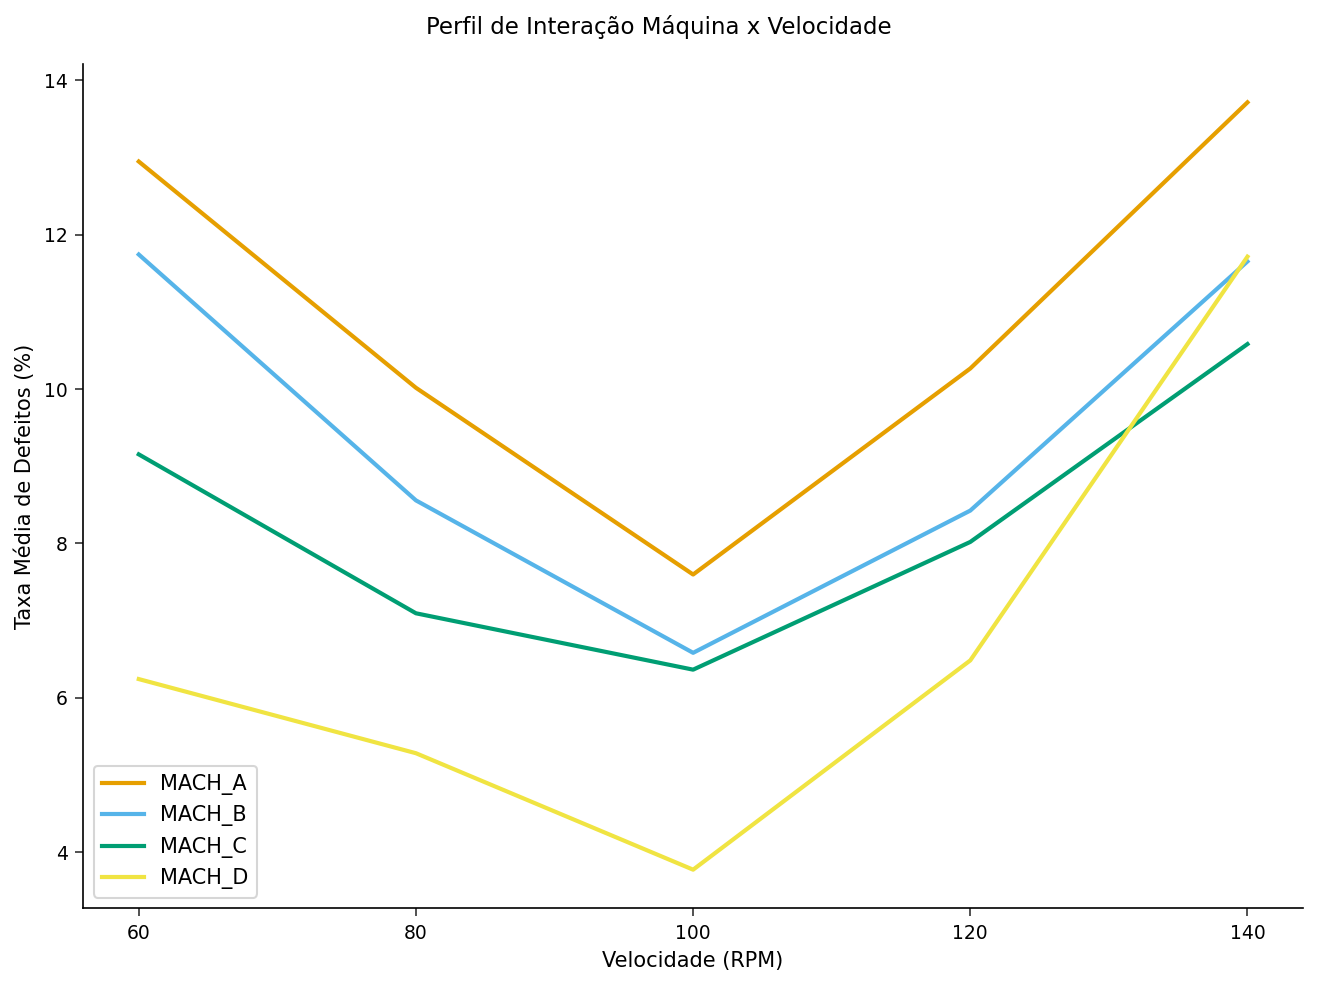

In [3]:
/* --------------------------------------------------------
   Gráfico de interação: taxa média de defeitos por velocidade e máquina
   -------------------------------------------------------- */
PROCEDIMENTO MÉDIAS DADOS=work.molding_experiment NOPRINT;
    CLASSE machine speed;
    VARIÁVEL defect_rate;
    SAÍDA out=work.cell_means mean=mean_defect;
EXECUTAR;

PROCEDIMENTO SGPLOT DADOS=work.cell_means(ONDE=(_type_=3));
    SERIES x=speed y=mean_defect / GROUP=machine
        LINEATTRS=(thickness=2) MARKERS;
    XAXIS LABEL='Velocidade (RPM)' VALUES=(60 80 100 120 140);
    YAXIS LABEL='Taxa Média de Defeitos (%)';
    TÍTULO 'Perfil de Interação Máquina x Velocidade';
EXECUTAR;

---

                            Taxa de Defeitos e Resistência à Tração por Máquina e Velocidade                            

              The Mixed Procedure              
               Model Information               

Item                                      Value
-------------------------  --------------------
Dependent Variable         Taxa de Defeitos (%)
Estimation Method                          REML
Degrees of Freedom Method         Kenward-Roger
Number of Observations                      100

Covariance Parameter Estimates

Cov Parm   Subject   Estimate
---------  --------  --------
Intercept  machine     3.1033
Residual               1.6566

            Type III Tests of Fixed Effects             

Effect              Num DF    Den DF   F Value    Pr > F
----------------  --------  --------  --------  --------
Velocidade (RPM)         4      92.0     60.26    <.0001

         Fit Statistics          

Statistic                   Value
-----------------------  --------
-2 Res


NOTE: PROC MIXED data=work.molding_experiment

NOTE: PROC MIXED: using R wrapper (mixed_renderer.R).
NOTE: PROC MIXED results written to: ./ods_output/mixed_results.spec.json
NOTE: lmer formula: defect_rate ~ speed_label + (1 | machine)
NOTE: Warning message:
NOTE: In readLines(con = "stdin") : incomplete final line found on 'stdin'
NOTE: ODS plot written: mixed_residuals_vs_predicted.spec.json
NOTE: ODS plot written: mixed_residual_histogram_panel.spec.json
NOTE: ODS plot written: mixed_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: mixed_qq_plot.spec.json
NOTE: ODS plot written: mixed_diagnostics.spec.json
NOTE: PROC MIXED ODS Graphics generated.
NOTE: ODS OUTPUT: SolutionF written to 'split_fixed'.
NOTE: ODS OUTPUT: CovParms written to 'split_covparms'.
NOTE: ODS OUTPUT: LSMeans written to 'speed_lsmeans'.
NOTE: ODS OUTPUT: FitStatistics written to 'split_fit'.
NOTE: ODS OUTPUT: Diffs written to 'speed_diffs'.


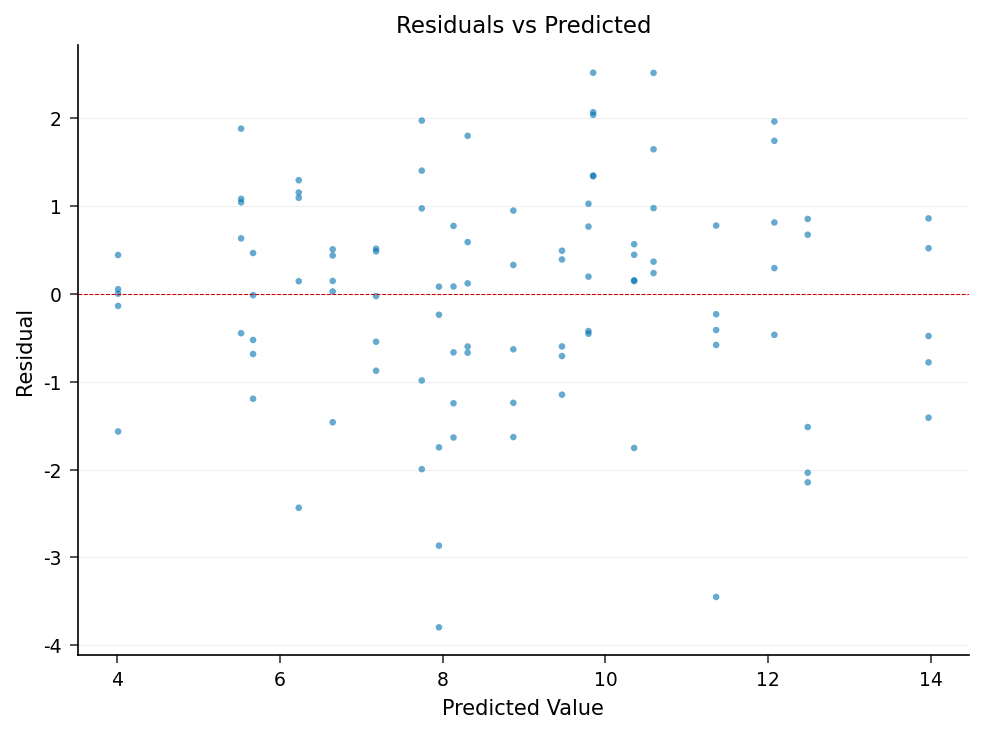

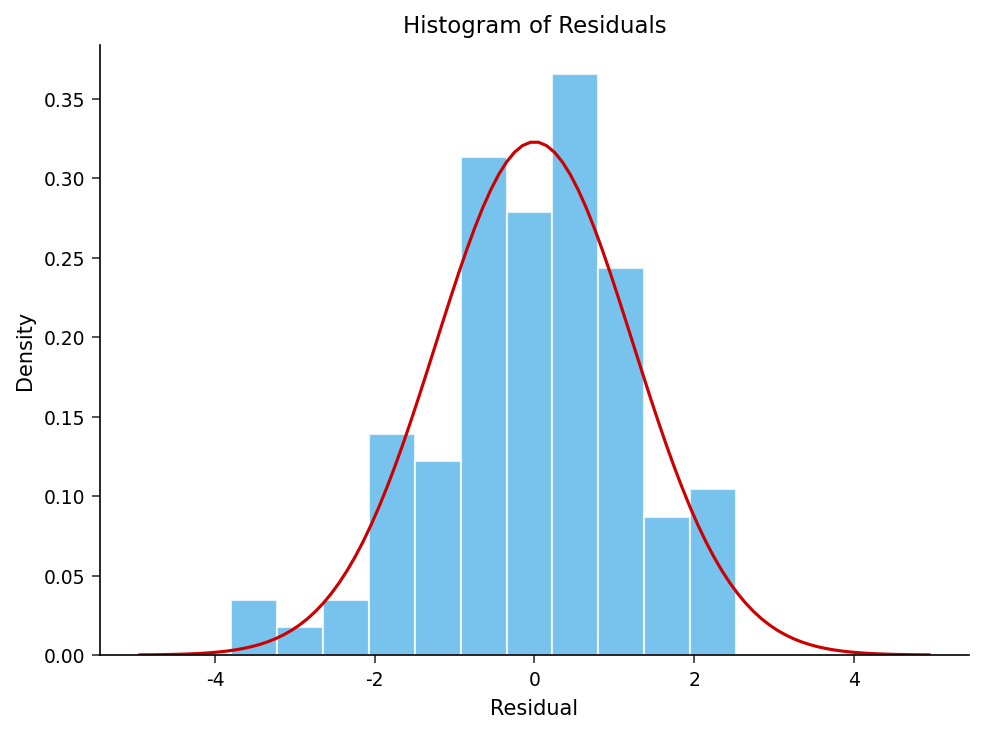

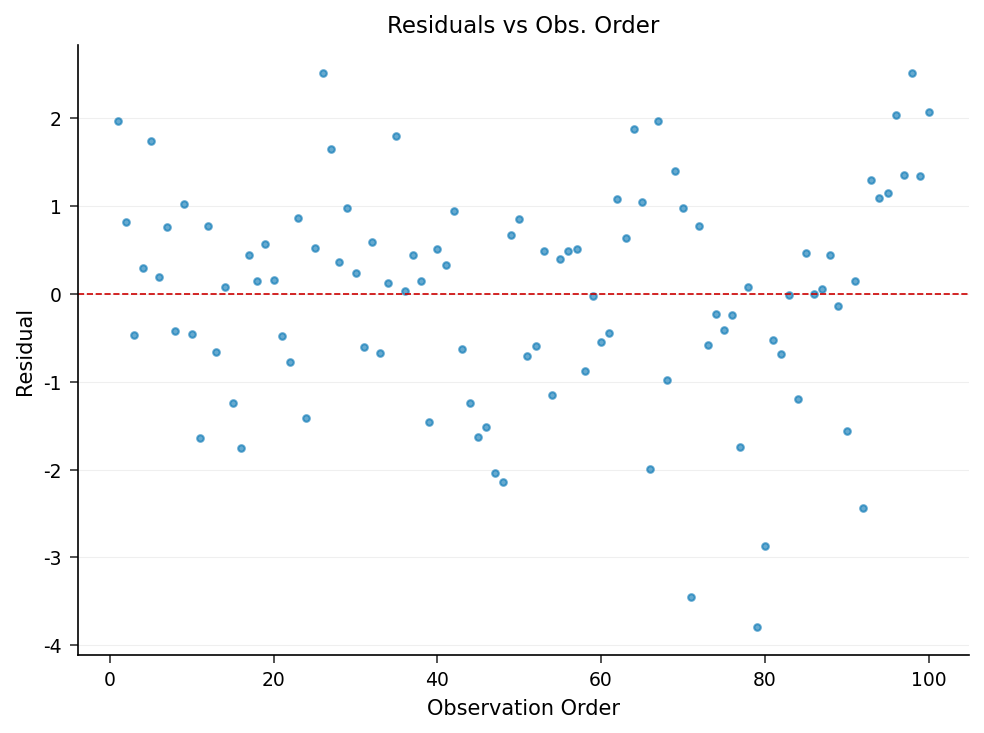

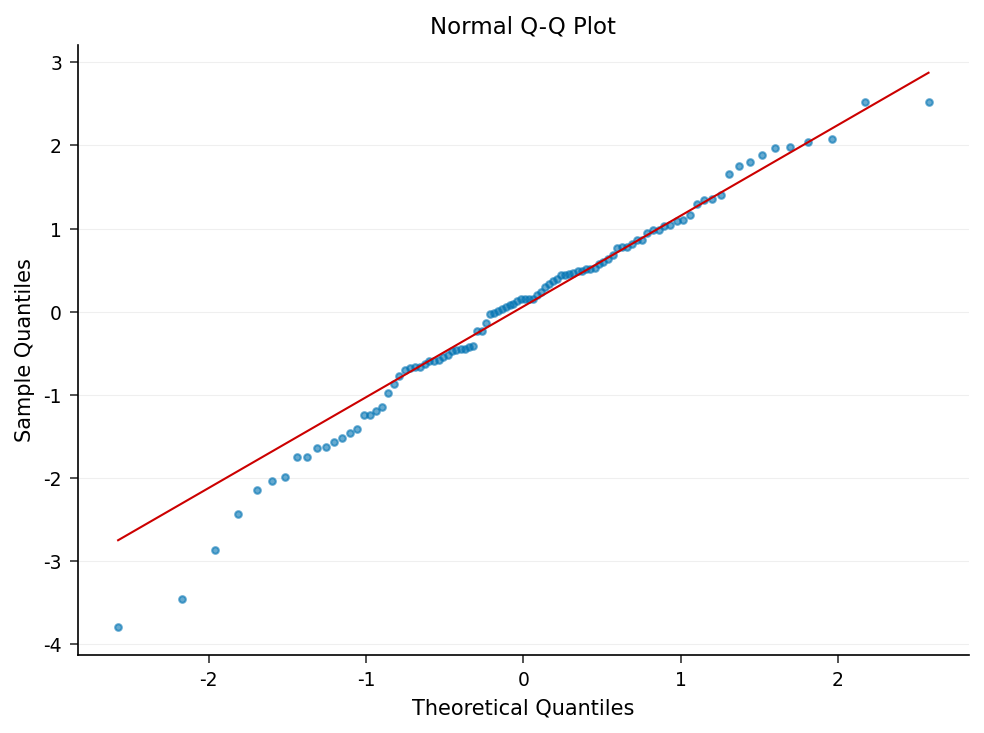

In [4]:
/* --------------------------------------------------------
   Análise do modelo misto em parcelas subdivididas
   Máquina é aleatória (erro da parcela principal)
   Velocidade é fixa (fator de subparcela)
   -------------------------------------------------------- */
PROCEDIMENTO MIXED DADOS=work.molding_experiment METHOD=reml;
    CLASSE machine speed_label;
    MODELO defect_rate = speed_label / SOLUTION ddfm=kr;
    RANDOM machine;
    LSMEANS speed_label / ADJUST=TUKEY DIFF cl;
    LABEL defect_rate="Taxa de Defeitos (%)" speed_label="Velocidade (RPM)";
    ODS OUTPUT LSMEANS=work.speed_lsmeans
              diffs=work.speed_diffs
              covparms=work.split_covparms
              fitstatistics=work.split_fit
              solutionf=work.split_fixed;
    TÍTULO 'Análise em Parcelas Subdivididas: Efeito da Velocidade na Taxa de Defeitos';
EXECUTAR;

In [5]:
/* --------------------------------------------------------
   Identificar o ajuste de velocidade ótimo
   -------------------------------------------------------- */
PROCEDIMENTO ORDENAR DADOS=work.speed_lsmeans;
    POR estimate;
EXECUTAR;

DADOS work.optimal_speed;
    DEFINIR work.speed_lsmeans(obs=1);
    MANTER speed_label estimate stderr LOWER UPPER;
    LABEL speed_label = 'Velocidade Ótima'
          estimate = 'Taxa de Defeitos LS-Mean'
          LOWER = 'IC 95% Inferior'
          UPPER = 'IC 95% Superior';
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=work.optimal_speed noobs LABEL;
    TÍTULO 'Velocidade de Operação Recomendada para Defeito Mínimo';
EXECUTAR;

                                 Velocidade de Operação Recomendada para Defeito Mínimo                                 

 Velocidade Ótima  Taxa de Defeitos LS-Mean  StdErr  IC 95% Inferior  IC 95% Superior
                .                     6.081  0.9266           3.3645           8.7975




NOTE: PROC SORT data=work.speed_lsmeans

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 5 rows from work.speed_lsmeans.
NOTE: Wrote work.speed_lsmeans (5 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.optimal_speed


NOTE: Read 1 rows from work.speed_lsmeans.
NOTE: Wrote work.optimal_speed (1 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.optimal_speed

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


In [6]:
/* --------------------------------------------------------
   Decomposição dos componentes de variância
   -------------------------------------------------------- */
PROCEDIMENTO IMPRIMIR DADOS=work.split_covparms noobs;
    TÍTULO 'Componentes de Variância: Máquina vs Residual';
EXECUTAR;

                                     Componentes de Variância: Máquina vs Residual                                      

  COVPARM  ESTIMATE
Intercept    3.1033
Residual     1.6566




NOTE: PROC PRINT data=work.split_covparms

NOTE: PROC PRINT completed: 2 observations printed, 2 variables


---

### Interpretação

O modelo em parcelas subdivididas particiona a variabilidade da taxa de defeitos em dois estratos. O **componente de variância da máquina (parcela principal) é 3.10** e a **variância residual (subparcela) é 1.66**, então as diferenças entre máquinas respondem por cerca de **65%** da variância total (3.10 / (3.10 + 1.66)). Essa grande parcela entre máquinas confirma que a máquina é uma fonte genuína de variação do processo e que o delineamento em parcelas subdivididas - em vez de uma análise totalmente aleatorizada - é o enquadramento correto.

O teste Tipo III do efeito fixo de velocidade é altamente significativo: **F(4, 92) = 60.26, p < .0001**, então o ajuste de RPM afeta fortemente a taxa de defeitos. As médias de mínimos quadrados traçam uma resposta quadrática clara com um mínimo na velocidade intermediária:

| Velocidade | Taxa de defeitos LS-mean (%) | IC 95% |
|-------|------------------------|--------|
| **100 RPM** | **6.08** | 3.36 - 8.80 |
| 80 RPM | 7.74 | 5.02 - 10.46 |
| 120 RPM | 8.30 | 5.58 - 11.02 |
| 60 RPM | 10.02 | 7.31 - 12.74 |
| 140 RPM | 11.92 | 9.20 - 14.63 |

As comparações par a par ajustadas por Tukey mostram que **100 RPM é significativamente menor do que todos os demais ajustes** (p ajustado <= 0.0009 contra 80, 120, 60 e 140 RPM). Os ajustes de 80 RPM e 120 RPM ficam no meio e **não** diferem entre si (diferença 0.56, p ajustado = 0.6430), enquanto 60 RPM e 140 RPM produzem as maiores taxas de defeitos.

**Recomendação de engenharia:** padronizar a produção em **100 RPM** em todas as quatro máquinas, onde o modelo estima a menor taxa de defeitos (6.08%). Como o componente de variância da máquina (3.10) é a fonte dominante de variabilidade, o trabalho de acompanhamento deve visar a calibração específica de cada máquina - o perfil de interação mostra que a MACH_D roda de forma consistentemente mais baixa e a MACH_A mais alta - para fechar a diferença entre as máquinas no ponto de ajuste escolhido de 100 RPM.

---

In [7]:
/* --------------------------------------------------------
   Exportar resultados da otimização de velocidade para engenharia
   -------------------------------------------------------- */
PROCEDIMENTO EXPORT DADOS=work.speed_lsmeans
    OUTFILE='speed_optimization_lsmeans.csv'
    DBMS=csv REPLACE;
EXECUTAR;

PROCEDIMENTO EXPORT DADOS=work.split_covparms
    OUTFILE='variance_components.csv'
    DBMS=csv REPLACE;
EXECUTAR;


NOTE: PROC EXPORT data=work.speed_lsmeans outfile=speed_optimization_lsmeans.csv

NOTE: Exported 5 rows to speed_optimization_lsmeans.csv.
NOTE: PROC EXPORT data=work.split_covparms outfile=variance_components.csv

NOTE: Exported 2 rows to variance_components.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Desenvolvido por <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>